In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import glob
import json
import copy
import random
import numpy as np
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt

from sklearn.metrics import accuracy_score, f1_score, classification_report

# =========================================================
# CONFIG
# =========================================================
DATA_DIR = "/content/drive/MyDrive/processed_meg_regression"

BATCH_SIZE = 8
EPOCHS = 100
LR = 8e-5
WEIGHT_DECAY = 1e-4
RUN_SEED = 42

WINDOW_SIZE = 2048
WINDOW_STRIDE = 1024

EARLY_STOPPING_PATIENCE = 12
MIN_DELTA = 1e-4

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

torch.manual_seed(RUN_SEED)
np.random.seed(RUN_SEED)
random.seed(RUN_SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

# =========================================================
# JSON HELPER
# =========================================================
def to_python(obj):
    if isinstance(obj, dict):
        return {k: to_python(v) for k, v in obj.items()}
    elif isinstance(obj, list):
        return [to_python(v) for v in obj]
    elif isinstance(obj, tuple):
        return [to_python(v) for v in obj]
    elif isinstance(obj, np.integer):
        return int(obj)
    elif isinstance(obj, np.floating):
        return float(obj)
    elif isinstance(obj, np.ndarray):
        return obj.tolist()
    else:
        return obj

# =========================================================
# WINDOWING
# =========================================================
def extract_windows_from_trial(trial_x, trial_y, window_size=2048, stride=1024):
    c, t = trial_x.shape
    xs = []
    start = 0

    while start + window_size <= t:
        xs.append(trial_x[:, start:start + window_size])
        start += stride

    if len(xs) == 0:
        return None, None

    return np.stack(xs).astype(np.float32), np.array(trial_y, dtype=np.float32)

# =========================================================
# LOADING
# =========================================================
def extract_subject_id_from_path(x_path):
    base = os.path.basename(x_path)
    return base.split("_")[0]

def load_all_trials_with_subjects(data_dir):
    x_paths = sorted(glob.glob(os.path.join(data_dir, "*_X.npy")))
    print(f"Searching in: {data_dir}")
    print(f"Found {len(x_paths)} X files")

    seq_x_list, y_list, subject_list = [], [], []

    for x_path in x_paths:
        y_path = x_path.replace("_X.npy", "_y.npy")
        if not os.path.exists(y_path):
            print(f"[WARN] Missing y file for: {x_path}")
            continue

        subject_id = extract_subject_id_from_path(x_path)
        X = np.load(x_path)
        y = np.load(y_path)

        n = min(len(X), len(y))
        X, y = X[:n], y[:n]

        for i in range(n):
            seq_x, y_trial = extract_windows_from_trial(
                X[i], y[i],
                window_size=WINDOW_SIZE,
                stride=WINDOW_STRIDE
            )
            if seq_x is not None:
                seq_x_list.append(seq_x)
                y_list.append(y_trial)
                subject_list.append(subject_id)

    print(f"Total usable trial sequences: {len(seq_x_list)}")
    print(f"Total unique subjects: {len(set(subject_list))}")
    return seq_x_list, y_list, subject_list

def filter_by_subjects(seq_x_list, y_list, subject_list, allowed_subjects):
    out_x, out_y = [], []
    for x, y, s in zip(seq_x_list, y_list, subject_list):
        if s in allowed_subjects:
            out_x.append(x)
            out_y.append(y)
    return out_x, out_y

# =========================================================
# LABEL CONVERSION FOR AROUSAL ONLY
# =========================================================
def compute_train_arousal_threshold(train_y_list):
    Y_train = np.stack(train_y_list, axis=0)
    arousal_thresh = np.median(Y_train[:, 1])
    return float(arousal_thresh)

def make_arousal_binary_labels(y_list, arousal_thresh):
    Y = np.stack(y_list, axis=0)
    arousal_labels = (Y[:, 1] >= arousal_thresh).astype(np.int64)
    return arousal_labels

# =========================================================
# DATASET
# =========================================================
class TrialBinaryDataset(Dataset):
    def __init__(self, seq_x_list, labels):
        self.seq_x_list = seq_x_list
        self.labels = labels.astype(np.float32)

    def __len__(self):
        return len(self.seq_x_list)

    def __getitem__(self, idx):
        x_seq = torch.tensor(self.seq_x_list[idx], dtype=torch.float32)
        y = torch.tensor(self.labels[idx], dtype=torch.float32)
        return x_seq, y

# =========================================================
# NORMALIZATION
# =========================================================
def compute_train_stats(dataset_subset):
    xs = []

    for x_seq, _ in dataset_subset:
        xs.append(x_seq.numpy())

    X = np.concatenate(xs, axis=0)  # (all_windows, C, T)

    x_mean = X.mean(axis=(0, 2), keepdims=True)
    x_std = X.std(axis=(0, 2), keepdims=True) + 1e-6

    return (
        x_mean.astype(np.float32),
        x_std.astype(np.float32),
    )

class NormalizedClassificationDataset(Dataset):
    def __init__(self, base_dataset, x_mean, x_std):
        self.base_dataset = base_dataset
        self.x_mean = torch.tensor(x_mean, dtype=torch.float32)
        self.x_std = torch.tensor(x_std, dtype=torch.float32)

    def __len__(self):
        return len(self.base_dataset)

    def __getitem__(self, idx):
        x_seq, y = self.base_dataset[idx]

        x_seq = (x_seq - self.x_mean) / self.x_std
        x_seq = x_seq - x_seq.mean(dim=-1, keepdim=True)
        x_seq = x_seq / (x_seq.std(dim=-1, keepdim=True) + 1e-6)
        x_seq = x_seq / (x_seq.abs().max(dim=-1, keepdim=True)[0] + 1e-6)

        return x_seq, y

# =========================================================
# LOSS
# =========================================================
class BCEWithSoftF1Loss(nn.Module):
    def __init__(self, pos_weight=None, lambda_bce=1.0, lambda_softf1=0.35, eps=1e-8):
        super().__init__()
        self.lambda_bce = lambda_bce
        self.lambda_softf1 = lambda_softf1
        self.eps = eps

        if pos_weight is not None:
            self.pos_weight = float(pos_weight)
        else:
            self.pos_weight = None

    def forward(self, logits, targets):
        targets = targets.float().view(-1)
        logits = logits.view(-1)

        if self.pos_weight is not None:
            pos_weight_tensor = torch.tensor(
                [self.pos_weight],
                dtype=logits.dtype,
                device=logits.device
            )
            bce = nn.functional.binary_cross_entropy_with_logits(
                logits,
                targets,
                pos_weight=pos_weight_tensor
            )
        else:
            bce = nn.functional.binary_cross_entropy_with_logits(logits, targets)

        probs = torch.sigmoid(logits)

        tp = torch.sum(probs * targets)
        fp = torch.sum(probs * (1.0 - targets))
        fn = torch.sum((1.0 - probs) * targets)

        soft_f1 = (2.0 * tp + self.eps) / (2.0 * tp + fp + fn + self.eps)
        soft_f1_loss = 1.0 - soft_f1

        return self.lambda_bce * bce + self.lambda_softf1 * soft_f1_loss

# =========================================================
# MODEL
# =========================================================
class PlainCNNEncoder(nn.Module):
    def __init__(self, in_channels=143, feature_dim=384, dropout=0.15):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv1d(in_channels, 64, kernel_size=7, padding=3),
            nn.BatchNorm1d(64),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(64, 128, kernel_size=5, padding=2),
            nn.BatchNorm1d(128),
            nn.ReLU(),
            nn.MaxPool1d(2),

            nn.Conv1d(128, feature_dim, kernel_size=3, padding=1),
            nn.BatchNorm1d(feature_dim),
            nn.ReLU(),
            nn.AdaptiveAvgPool1d(1)
        )
        self.dropout = nn.Dropout(dropout)

    def forward(self, x):
        x = self.net(x)
        x = x.squeeze(-1)
        x = self.dropout(x)
        return x

class AttentionPooling(nn.Module):
    def __init__(self, input_dim, attn_dim=128, dropout=0.15):
        super().__init__()
        self.attn = nn.Sequential(
            nn.Linear(input_dim, attn_dim),
            nn.Tanh(),
            nn.Dropout(dropout),
            nn.Linear(attn_dim, 1)
        )

    def forward(self, x):
        # x: [B, W, D]
        scores = self.attn(x)                    # [B, W, 1]
        weights = torch.softmax(scores, dim=1)  # [B, W, 1]
        pooled = torch.sum(weights * x, dim=1)  # [B, D]
        return pooled, weights

class ArousalCNNBiLSTMAttnFusion(nn.Module):
    def __init__(self, in_channels=143, cnn_feature_dim=384, lstm_hidden=192, dropout=0.15):
        super().__init__()

        self.encoder = PlainCNNEncoder(
            in_channels=in_channels,
            feature_dim=cnn_feature_dim,
            dropout=dropout
        )

        self.temporal_bilstm = nn.LSTM(
            input_size=cnn_feature_dim,
            hidden_size=lstm_hidden,
            num_layers=2,
            batch_first=True,
            bidirectional=True,
            dropout=dropout
        )

        self.cnn_attn_pool = AttentionPooling(
            input_dim=cnn_feature_dim,
            attn_dim=128,
            dropout=dropout
        )

        self.lstm_attn_pool = AttentionPooling(
            input_dim=lstm_hidden * 2,
            attn_dim=128,
            dropout=dropout
        )

        self.cnn_proj = nn.Sequential(
            nn.Linear(cnn_feature_dim, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.lstm_proj = nn.Sequential(
            nn.Linear(lstm_hidden * 2, 128),
            nn.ReLU(),
            nn.Dropout(dropout)
        )

        self.gate = nn.Sequential(
            nn.Linear(256, 128),
            nn.Sigmoid()
        )

        self.head = nn.Sequential(
            nn.Linear(128, 64),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x_seq):
        # x_seq: [B, W, C, T]
        B, W, C, T = x_seq.shape

        x = x_seq.reshape(B * W, C, T)
        z = self.encoder(x)                 # [B*W, F]
        z = z.reshape(B, W, -1)             # [B, W, F]

        z_cnn, cnn_weights = self.cnn_attn_pool(z)   # [B, F]
        z_cnn = self.cnn_proj(z_cnn)                 # [B, 128]

        z_lstm, _ = self.temporal_bilstm(z)          # [B, W, 2H]
        z_lstm, lstm_weights = self.lstm_attn_pool(z_lstm)
        z_lstm = self.lstm_proj(z_lstm)              # [B, 128]

        z_cat = torch.cat([z_cnn, z_lstm], dim=1)    # [B, 256]
        g = self.gate(z_cat)                         # [B, 128]

        z_fused = g * z_lstm + (1.0 - g) * z_cnn
        logits = self.head(z_fused).squeeze(1)       # [B]

        return logits, cnn_weights, lstm_weights

# =========================================================
# METRICS
# =========================================================
def compute_classification_metrics(y_true, y_pred):
    acc = accuracy_score(y_true, y_pred)
    f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
    return acc, f1

def find_best_threshold(y_true, y_prob):
    best_thr = 0.5
    best_f1 = -1.0

    for thr in np.arange(0.30, 0.71, 0.02):
        y_pred = (y_prob >= thr).astype(np.int64)
        f1 = f1_score(y_true, y_pred, average="binary", zero_division=0)
        if f1 > best_f1:
            best_f1 = f1
            best_thr = float(thr)

    return best_thr, best_f1

# =========================================================
# TRAIN / EVAL
# =========================================================
def train_one_epoch(model, loader, optimizer, criterion):
    model.train()
    total_loss = 0.0

    for x_seq, y in loader:
        x_seq = x_seq.to(DEVICE)
        y = y.to(DEVICE)

        logits, _, _ = model(x_seq)
        loss = criterion(logits, y)

        optimizer.zero_grad()
        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
        optimizer.step()

        total_loss += loss.item()

    return {"loss": total_loss / len(loader)}

@torch.no_grad()
def evaluate_probs(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    all_true = []
    all_prob = []

    for x_seq, y in loader:
        x_seq = x_seq.to(DEVICE)
        y = y.to(DEVICE)

        logits, _, _ = model(x_seq)
        loss = criterion(logits, y)
        total_loss += loss.item()

        probs = torch.sigmoid(logits)

        all_true.append(y.cpu().numpy())
        all_prob.append(probs.cpu().numpy())

    y_true = np.concatenate(all_true).astype(np.int64)
    y_prob = np.concatenate(all_prob)

    return {
        "loss": total_loss / len(loader),
        "y_true": y_true,
        "y_prob": y_prob,
    }

@torch.no_grad()
def evaluate_with_threshold(model, loader, criterion, threshold=0.5):
    raw = evaluate_probs(model, loader, criterion)
    y_true = raw["y_true"]
    y_prob = raw["y_prob"]
    y_pred = (y_prob >= threshold).astype(np.int64)

    acc, f1 = compute_classification_metrics(y_true, y_pred)

    return {
        "loss": raw["loss"],
        "accuracy": acc,
        "f1": f1,
        "y_true": y_true,
        "y_prob": y_prob,
        "y_pred": y_pred,
    }

# =========================================================
# CURVE PLOTTING
# =========================================================
def save_fold_curves(history, held_out_subject):
    epochs = range(1, len(history["train_loss"]) + 1)

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["train_loss"], label="Train Loss")
    plt.plot(epochs, history["val_loss"], label="Val Loss")
    plt.xlabel("Epoch")
    plt.ylabel("Loss")
    plt.title(f"Arousal Loss Curves - Held-out {held_out_subject}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"curve_loss_arousal_only_{held_out_subject}.png")
    plt.close()

    plt.figure(figsize=(8, 5))
    plt.plot(epochs, history["val_acc"], label="Val Accuracy")
    plt.plot(epochs, history["val_f1"], label="Val F1")
    plt.xlabel("Epoch")
    plt.ylabel("Metric")
    plt.title(f"Arousal Metrics - Held-out {held_out_subject}")
    plt.legend()
    plt.tight_layout()
    plt.savefig(f"curve_metrics_arousal_only_{held_out_subject}.png")
    plt.close()

# =========================================================
# TRAIN ONE LOSO FOLD FOR AROUSAL ONLY
# =========================================================
def train_one_loso_fold_arousal(held_out_subject, seq_x_list, y_list, subject_list):
    train_subjects = sorted(list(set(subject_list) - {held_out_subject}))
    val_subjects = [held_out_subject]

    train_x, train_y_raw = filter_by_subjects(seq_x_list, y_list, subject_list, set(train_subjects))
    val_x, val_y_raw = filter_by_subjects(seq_x_list, y_list, subject_list, set(val_subjects))

    arousal_thresh = compute_train_arousal_threshold(train_y_raw)

    train_labels = make_arousal_binary_labels(train_y_raw, arousal_thresh)
    val_labels = make_arousal_binary_labels(val_y_raw, arousal_thresh)

    print("\n" + "=" * 70)
    print(f"LOSO FOLD | Held-out subject: {held_out_subject} | Task: arousal")
    print("=" * 70)
    print(f"Train trials: {len(train_x)}")
    print(f"Val trials:   {len(val_x)}")
    print(f"Train threshold arousal: {arousal_thresh:.4f}")
    print(f"Train class counts: {np.bincount(train_labels, minlength=2)}")
    print(f"Val class counts:   {np.bincount(val_labels, minlength=2)}")

    train_base = TrialBinaryDataset(train_x, train_labels)
    val_base = TrialBinaryDataset(val_x, val_labels)

    x_mean, x_std = compute_train_stats(train_base)
    train_set = NormalizedClassificationDataset(train_base, x_mean, x_std)
    val_set = NormalizedClassificationDataset(val_base, x_mean, x_std)

    train_loader = DataLoader(train_set, batch_size=BATCH_SIZE, shuffle=True, num_workers=0, pin_memory=True)
    val_loader = DataLoader(val_set, batch_size=BATCH_SIZE, shuffle=False, num_workers=0, pin_memory=True)

    model = ArousalCNNBiLSTMAttnFusion(
        in_channels=143,
        cnn_feature_dim=384,
        lstm_hidden=192,
        dropout=0.15
    ).to(DEVICE)

    class_counts = np.bincount(train_labels, minlength=2).astype(np.float32)
    neg_count, pos_count = class_counts[0], class_counts[1]
    pos_weight = neg_count / max(pos_count, 1.0)

    criterion = BCEWithSoftF1Loss(
        pos_weight=pos_weight,
        lambda_bce=1.0,
        lambda_softf1=0.35
    )

    optimizer = torch.optim.AdamW(model.parameters(), lr=LR, weight_decay=WEIGHT_DECAY)

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode="max",
        factor=0.5,
        patience=5
    )

    best_score = -float("inf")
    best_epoch = -1
    best_checkpoint = None
    epochs_without_improvement = 0

    history = {
        "train_loss": [],
        "val_loss": [],
        "val_acc": [],
        "val_f1": [],
        "val_thr": [],
    }

    for epoch in range(1, EPOCHS + 1):
        train_metrics = train_one_epoch(model, train_loader, optimizer, criterion)

        train_raw = evaluate_probs(model, train_loader, criterion)
        epoch_thr, _ = find_best_threshold(train_raw["y_true"], train_raw["y_prob"])

        val_metrics = evaluate_with_threshold(
            model,
            val_loader,
            criterion,
            threshold=epoch_thr
        )

        score = val_metrics["f1"]
        scheduler.step(score)

        history["train_loss"].append(train_metrics["loss"])
        history["val_loss"].append(val_metrics["loss"])
        history["val_acc"].append(val_metrics["accuracy"])
        history["val_f1"].append(val_metrics["f1"])
        history["val_thr"].append(epoch_thr)

        current_lr = optimizer.param_groups[0]["lr"]

        print(
            f"Held-out {held_out_subject} | arousal | Epoch {epoch:03d} | "
            f"LR: {current_lr:.6f} | "
            f"Train Loss: {train_metrics['loss']:.4f} | "
            f"Val Loss: {val_metrics['loss']:.4f} | "
            f"Val Acc: {val_metrics['accuracy']:.4f} | "
            f"Val F1: {val_metrics['f1']:.4f} | "
            f"Thr: {epoch_thr:.2f}"
        )

        improved = score > (best_score + MIN_DELTA)

        if improved:
            best_score = score
            best_epoch = epoch
            epochs_without_improvement = 0

            best_checkpoint = {
                "held_out_subject": held_out_subject,
                "epoch": epoch,
                "score": score,
                "accuracy": val_metrics["accuracy"],
                "f1": val_metrics["f1"],
                "decision_threshold": epoch_thr,
                "y_true": val_metrics["y_true"],
                "y_pred": val_metrics["y_pred"],
                "y_prob": val_metrics["y_prob"],
                "arousal_thresh": arousal_thresh,
            }

            torch.save(
                {
                    "held_out_subject": held_out_subject,
                    "task_name": "arousal",
                    "epoch": epoch,
                    "model_state_dict": copy.deepcopy(model.state_dict()),
                    "accuracy": val_metrics["accuracy"],
                    "f1": val_metrics["f1"],
                    "decision_threshold": epoch_thr,
                    "arousal_thresh": arousal_thresh,
                },
                f"best_model_arousal_only_{held_out_subject}.pt"
            )

            print(
                f"🔥 Best fold updated | "
                f"Epoch {epoch} | "
                f"Acc: {val_metrics['accuracy']:.4f} | "
                f"F1: {val_metrics['f1']:.4f} | "
                f"Thr: {epoch_thr:.2f}"
            )
        else:
            epochs_without_improvement += 1

        if epochs_without_improvement >= EARLY_STOPPING_PATIENCE:
            print(
                f"Early stopping for held-out {held_out_subject} at epoch {epoch}. "
                f"Best epoch was {best_epoch}."
            )
            break

    if best_checkpoint is None:
        raise RuntimeError(f"No best checkpoint saved for held-out subject {held_out_subject}")

    np.save(f"best_y_true_arousal_only_{held_out_subject}.npy", best_checkpoint["y_true"])
    np.save(f"best_y_pred_arousal_only_{held_out_subject}.npy", best_checkpoint["y_pred"])
    np.save(f"best_y_prob_arousal_only_{held_out_subject}.npy", best_checkpoint["y_prob"])

    save_fold_curves(history, held_out_subject)

    with open(f"history_arousal_only_{held_out_subject}.json", "w") as f:
        json.dump(to_python(history), f, indent=4)

    print("\nClassification report:")
    print(classification_report(best_checkpoint["y_true"], best_checkpoint["y_pred"], digits=4, zero_division=0))

    return {
        "held_out_subject": held_out_subject,
        "best_epoch": best_checkpoint["epoch"],
        "accuracy": best_checkpoint["accuracy"],
        "f1": best_checkpoint["f1"],
        "decision_threshold": best_checkpoint["decision_threshold"],
        "arousal_thresh": best_checkpoint["arousal_thresh"],
    }

# =========================================================
# RUN AROUSAL ACROSS ALL SUBJECTS
# =========================================================
def run_loso_arousal_only(seq_x_list, y_list, subject_list):
    unique_subjects = sorted(list(set(subject_list)))
    print(f"\nRunning LOSO binary classification for arousal across {len(unique_subjects)} subjects:")
    print(unique_subjects)

    all_fold_results = []

    for held_out_subject in unique_subjects:
        fold_result = train_one_loso_fold_arousal(
            held_out_subject,
            seq_x_list,
            y_list,
            subject_list
        )
        all_fold_results.append(fold_result)

    accs = np.array([r["accuracy"] for r in all_fold_results], dtype=np.float32)
    f1s = np.array([r["f1"] for r in all_fold_results], dtype=np.float32)

    summary = {
        "task_name": "arousal",
        "accuracy_mean": float(accs.mean()),
        "accuracy_std": float(accs.std()),
        "f1_mean": float(f1s.mean()),
        "f1_std": float(f1s.std()),
        "per_subject": all_fold_results,
    }

    with open("loso_arousal_only_summary.json", "w") as f:
        json.dump(to_python(summary), f, indent=4)

    print("\n" + "=" * 70)
    print("AROUSAL ONLY FINAL SUMMARY")
    print("=" * 70)
    print(f"Accuracy: {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
    print(f"F1:       {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")

    return summary

# =========================================================
# MAIN
# =========================================================
def main():
    print("Loading processed trials...")
    seq_x_list, y_list, subject_list = load_all_trials_with_subjects(DATA_DIR)

    if len(seq_x_list) == 0:
        raise FileNotFoundError(f"No processed trials found in {DATA_DIR}.")

    print("Example x_seq shape:", seq_x_list[0].shape)
    print("Example y shape:", y_list[0].shape)

    config = {
        "model": "ArousalCNNBiLSTMAttnFusion",
        "cnn_feature_dim": 384,
        "lstm_hidden": 192,
        "dropout": 0.15,
        "lr": LR,
        "epochs": EPOCHS,
        "evaluation": "LOSO binary classification",
        "task": "arousal only",
        "label_strategy": "global train-only threshold per fold",
        "threshold_type": "median",
        "loss": "BCEWithSoftF1Loss",
        "pooling": "attention over CNN windows + attention over BiLSTM windows",
        "fusion": "gated fusion of CNN attention summary and BiLSTM attention summary",
    }

    with open("loso_arousal_only_config.json", "w") as f:
        json.dump(to_python(config), f, indent=4)

    summary_arousal = run_loso_arousal_only(seq_x_list, y_list, subject_list)

    with open("loso_arousal_only_final_summary.json", "w") as f:
        json.dump(to_python(summary_arousal), f, indent=4)

    print("\nSaved:")
    print("  loso_arousal_only_config.json")
    print("  loso_arousal_only_summary.json")
    print("  loso_arousal_only_final_summary.json")
    print("  best_model_arousal_only_<subject>.pt")
    print("  best_y_true_arousal_only_<subject>.npy")
    print("  best_y_pred_arousal_only_<subject>.npy")
    print("  best_y_prob_arousal_only_<subject>.npy")
    print("  history_arousal_only_<subject>.json")
    print("  curve_loss_arousal_only_<subject>.png")
    print("  curve_metrics_arousal_only_<subject>.png")

if __name__ == "__main__":
    main()

Loading processed trials...
Searching in: /content/drive/MyDrive/processed_meg_regression
Found 82 X files
Total usable trial sequences: 814
Total unique subjects: 21
Example x_seq shape: (4, 143, 2048)
Example y shape: (2,)

Running LOSO binary classification for arousal across 21 subjects:
['sub-01', 'sub-02', 'sub-03', 'sub-04', 'sub-05', 'sub-06', 'sub-07', 'sub-08', 'sub-09', 'sub-10', 'sub-11', 'sub-14', 'sub-15', 'sub-16', 'sub-17', 'sub-18', 'sub-19', 'sub-20', 'sub-21', 'sub-22', 'sub-23']

LOSO FOLD | Held-out subject: sub-01 | Task: arousal
Train trials: 774
Val trials:   40
Train threshold arousal: 0.5000
Train class counts: [313 461]
Val class counts:   [10 30]
Held-out sub-01 | arousal | Epoch 001 | LR: 0.000080 | Train Loss: 0.7060 | Val Loss: 0.6159 | Val Acc: 0.7500 | Val F1: 0.8571 | Thr: 0.30
🔥 Best fold updated | Epoch 1 | Acc: 0.7500 | F1: 0.8571 | Thr: 0.30
Held-out sub-01 | arousal | Epoch 002 | LR: 0.000080 | Train Loss: 0.6043 | Val Loss: 0.7394 | Val Acc: 0.75

In [ ]:
import zipfile
from google.colab import files
import os
import glob

# Define the patterns for the files the user wants to download
file_patterns = [
    'loso_arousal_only_config.json',
    'loso_arousal_only_summary.json',
    'loso_arousal_only_final_summary.json',
    'history_arousal_only_sub-??.json',
    'curve_loss_arousal_only_sub-??.png',
    'curve_metrics_arousal_only_sub-??.png'
]

# Collect all files matching the patterns in the current directory
files_to_zip = []
for pattern in file_patterns:
    files_to_zip.extend(glob.glob(pattern))

# Define the name of the zip file
zip_filename = 'loso_arousal_only_results.zip'

# Create the zip archive
with zipfile.ZipFile(zip_filename, 'w') as zipf:
    for file in files_to_zip:
        if os.path.exists(file):
            zipf.write(file, os.path.basename(file))
        else:
            print(f"[WARN] File not found when zipping: {file}")

print(f"Successfully created {zip_filename} containing {len(files_to_zip)} files.")

# Provide a download link for the zip file
files.download(zip_filename)

Successfully created loso_arousal_only_results.zip containing 66 files.


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

Found 21 subject files
Total samples: 814
Class counts: [323 491]


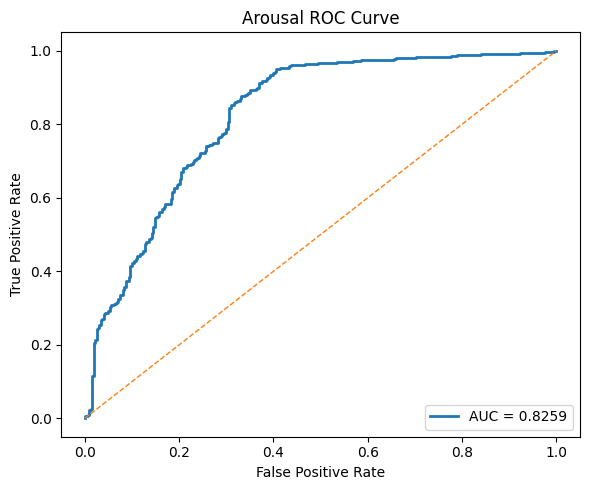

ROC AUC: 0.8259


<Figure size 500x500 with 0 Axes>

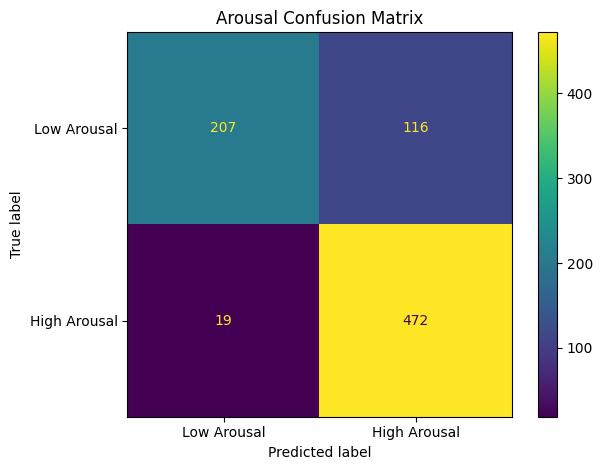

Confusion Matrix:
[[207 116]
 [ 19 472]]


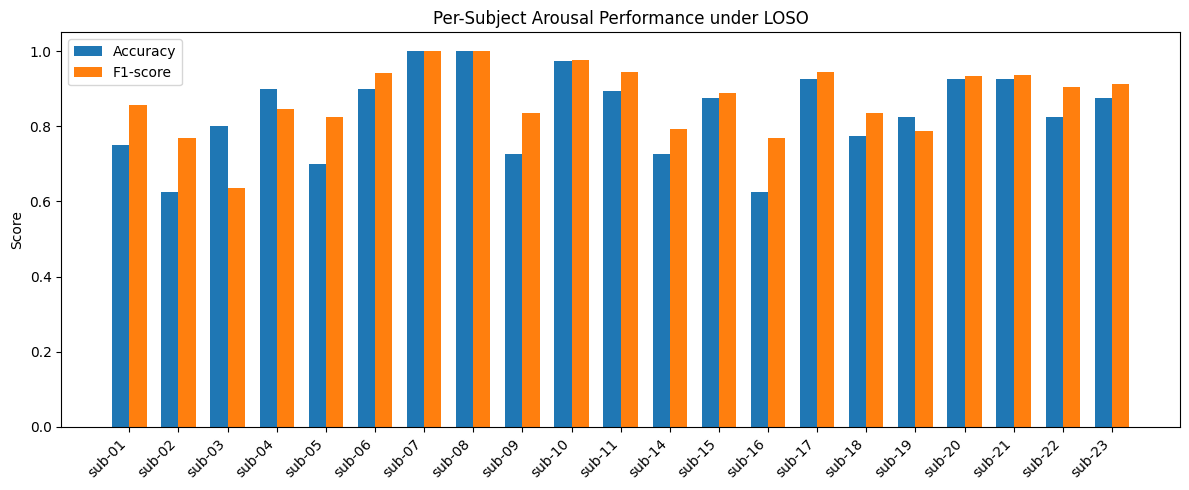


Arousal Summary
Accuracy: 0.8367 ± 0.1105
F1-score: 0.8732 ± 0.0889
ROC AUC:  0.8259

Saved figures:
  arousal_roc_auc.png
  arousal_confusion_matrix.png
  arousal_per_subject_accuracy_f1.png


In [ ]:
import os
import glob
import json
import numpy as np
import matplotlib.pyplot as plt

from sklearn.metrics import (
    roc_curve,
    auc,
    confusion_matrix,
    ConfusionMatrixDisplay
)

# =========================================================
# CONFIG
# =========================================================
RESULT_DIR = "."   # change if files are in another folder
TASK = "arousal_only"

SUMMARY_JSON = os.path.join(RESULT_DIR, "loso_arousal_only_final_summary.json")

# =========================================================
# 1. LOAD ALL SUBJECT PREDICTIONS
# =========================================================
y_true_all = []
y_prob_all = []
y_pred_all = []

true_files = sorted(glob.glob(os.path.join(RESULT_DIR, f"best_y_true_{TASK}_*.npy")))

print(f"Found {len(true_files)} subject files")

for true_path in true_files:
    subject = true_path.replace(os.path.join(RESULT_DIR, f"best_y_true_{TASK}_"), "")
    subject = subject.replace(".npy", "")

    prob_path = os.path.join(RESULT_DIR, f"best_y_prob_{TASK}_{subject}.npy")
    pred_path = os.path.join(RESULT_DIR, f"best_y_pred_{TASK}_{subject}.npy")

    if not os.path.exists(prob_path) or not os.path.exists(pred_path):
        print(f"Skipping {subject}: missing prob or pred file")
        continue

    y_true = np.load(true_path)
    y_prob = np.load(prob_path)
    y_pred = np.load(pred_path)

    y_true_all.append(y_true)
    y_prob_all.append(y_prob)
    y_pred_all.append(y_pred)

y_true_all = np.concatenate(y_true_all)
y_prob_all = np.concatenate(y_prob_all)
y_pred_all = np.concatenate(y_pred_all)

print("Total samples:", len(y_true_all))
print("Class counts:", np.bincount(y_true_all.astype(int)))

# =========================================================
# 2. ROC CURVE + AUC
# =========================================================
fpr, tpr, thresholds = roc_curve(y_true_all, y_prob_all)
roc_auc = auc(fpr, tpr)

plt.figure(figsize=(6, 5))
plt.plot(fpr, tpr, linewidth=2, label=f"AUC = {roc_auc:.4f}")
plt.plot([0, 1], [0, 1], linestyle="--", linewidth=1)
plt.xlabel("False Positive Rate")
plt.ylabel("True Positive Rate")
plt.title("Arousal ROC Curve")
plt.legend(loc="lower right")
plt.tight_layout()
plt.savefig("arousal_roc_auc.png", dpi=300)
plt.show()

print(f"ROC AUC: {roc_auc:.4f}")

# =========================================================
# 3. CONFUSION MATRIX
# =========================================================
cm = confusion_matrix(y_true_all, y_pred_all)

disp = ConfusionMatrixDisplay(
    confusion_matrix=cm,
    display_labels=["Low Arousal", "High Arousal"]
)

plt.figure(figsize=(5, 5))
disp.plot(values_format="d")
plt.title("Arousal Confusion Matrix")
plt.tight_layout()
plt.savefig("arousal_confusion_matrix.png", dpi=300)
plt.show()

print("Confusion Matrix:")
print(cm)

# =========================================================
# 4. PER-SUBJECT ACCURACY + F1 BAR PLOT
# =========================================================
with open(SUMMARY_JSON, "r") as f:
    summary = json.load(f)

per_subject = summary["per_subject"]

subjects = [r["held_out_subject"] for r in per_subject]
accuracies = [r["accuracy"] for r in per_subject]
f1s = [r["f1"] for r in per_subject]

x = np.arange(len(subjects))
width = 0.35

plt.figure(figsize=(12, 5))
plt.bar(x - width / 2, accuracies, width, label="Accuracy")
plt.bar(x + width / 2, f1s, width, label="F1-score")
plt.xticks(x, subjects, rotation=45, ha="right")
plt.ylabel("Score")
plt.ylim(0, 1.05)
plt.title("Per-Subject Arousal Performance under LOSO")
plt.legend()
plt.tight_layout()
plt.savefig("arousal_per_subject_accuracy_f1.png", dpi=300)
plt.show()

# =========================================================
# 5. PRINT FINAL SUMMARY
# =========================================================
print("\nArousal Summary")
print("=" * 40)
print(f"Accuracy: {summary['accuracy_mean']:.4f} ± {summary['accuracy_std']:.4f}")
print(f"F1-score: {summary['f1_mean']:.4f} ± {summary['f1_std']:.4f}")
print(f"ROC AUC:  {roc_auc:.4f}")

print("\nSaved figures:")
print("  arousal_roc_auc.png")
print("  arousal_confusion_matrix.png")
print("  arousal_per_subject_accuracy_f1.png")